In [1]:
import numpy as np
import pandas as pd
import seaborn as s
import matplotlib.pyplot as plt 
df = pd.read_csv("C:/Users/Manas Tiwari/Desktop/telecome data.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Convert value of SeniorCitizen column 0 change into No and 1 changes into Yes

In [2]:
def helo(SeniorCitizen):
    if SeniorCitizen == 0:
        return "No"
    else:
        return "Yes"
df["SeniorCitizen"] = df["SeniorCitizen"].apply(helo)

# Replace Null value with Zero

In [3]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Practice Questions.....

# Q.1 : Find the total percentage of left people ??

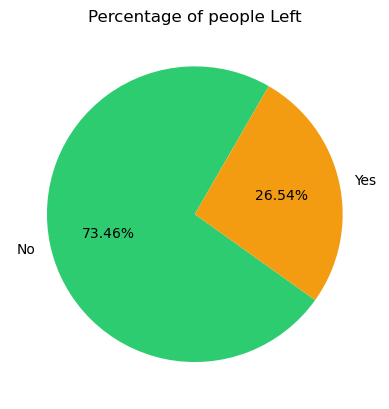

In [7]:
gp = df.groupby("Left").size()
unique_colors = [
      # light blue
    # light orange
    "#2ECC71",  # light purple
    "#F39C12"  # light pink-purple
]
plt.pie(gp,labels = gp.index,autopct = "%1.2f%%",startangle = 60,colors= unique_colors)
plt.title("Percentage of people Left")
plt.show()

conclusion : Most churned and non-churned customers are non-senior citizens, indicating their larger presence in the customer base. Senior citizens show lower churn in absolute numbers, but their churn rate relative to their total count may still require attention.

# Q.2 : Find the left person on the basis of gender ??


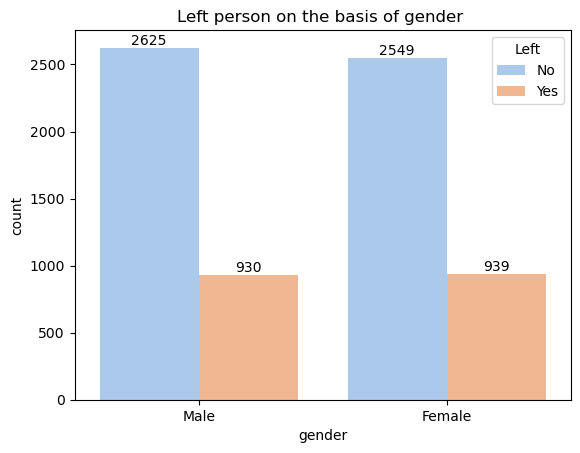

In [31]:
c = ['#a1c9f4', '#ffb482']
a = s.countplot(df,x = "gender",palette = c,hue = "Left")
for bars in a.containers:
    a.bar_label(bars)
plt.title("Left person on the basis of gender ")
plt.show()

conclusion:

Both male and female customers show a similar churn pattern.

However, slightly more males (930) than females (939) have stayed, indicating gender has minimal influence on churn behavior.

# Q.3 : Find the count of senoir citizen ??


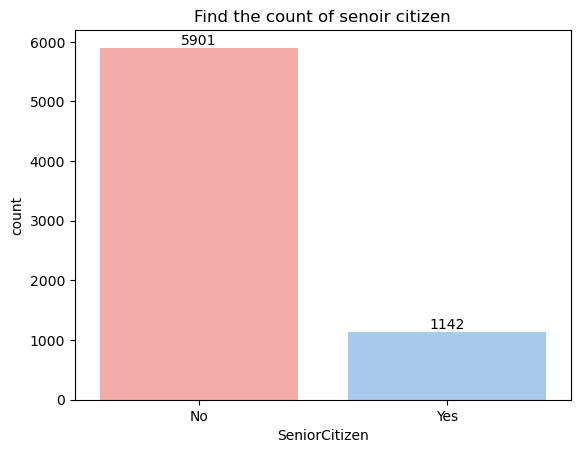

In [42]:
c = ['#ff9f9b', '#a1c9f4'] 
a = s.countplot(df,x = "SeniorCitizen",palette = c,hue = "SeniorCitizen")
for bars in a.containers:
    a.bar_label(bars)
plt.title("Find the count of senoir citizen")
plt.show()

conclusion : The majority of customers are not senior citizens, with a count of 5901 compared to only 1142 senior citizens. This suggests that younger customers form the core demographic base for the service or product.

# Q.4: Find the left person on the basis of senior Citizen ??

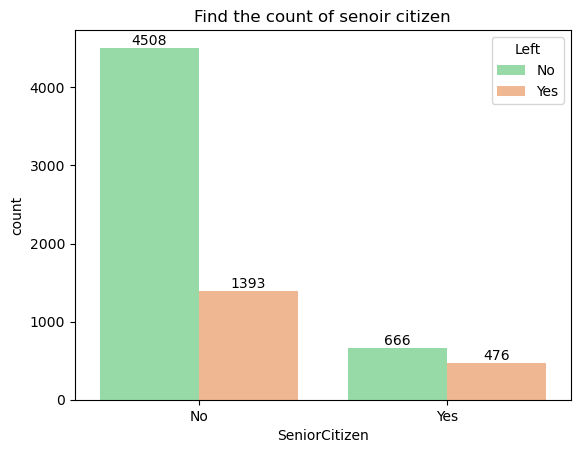

In [54]:
c = ['#8de5a1', '#ffb482']
a = s.countplot(df,x = "SeniorCitizen",palette = c,hue = "Left")
for bars in a.containers:
    a.bar_label(bars)
plt.title("Find the count of senoir citizen")
plt.show()

conclusion : Most churned and non-churned customers are non-senior citizens, indicating their larger presence in the customer base.
Senior citizens show lower churn in absolute numbers, but their churn rate relative to their total count may still require attention.

# Q.5 : Find the left person on the basis of Tenure ??

<Axes: xlabel='tenure', ylabel='Count'>

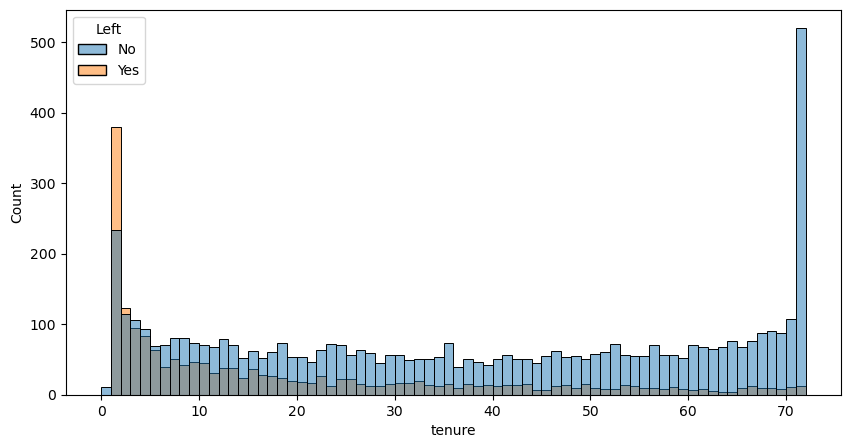

In [65]:
plt.figure(figsize = (10,5))
s.histplot(df,x = "tenure",bins = 72,hue = "Left")

conclusion : people who have used our services for a long time have stayed and people who have used our sevices 1 or 2 months have churned...

# Q.5 : Find the left person on the basis of Contract ??

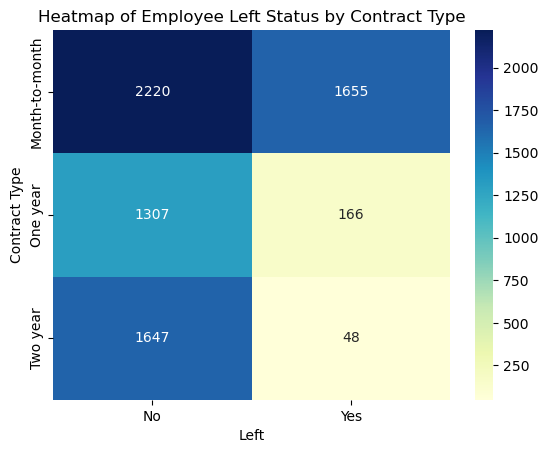

In [94]:
gp = df.groupby("Contract")["Left"].value_counts().unstack()
sns.heatmap(gp, annot=True, cmap="YlGnBu",fmt = ".0f")
plt.title("Heatmap of Employee Left Status by Contract Type")
plt.xlabel("Left")
plt.ylabel("Contract Type")
plt.show()


Conclusion : Customers with Month-to-month contracts have the highest churn rate, indicating instability in short-term commitments. In contrast, churn is significantly lower for customers with One year and especially Two year contracts, suggesting long-term contracts enhance customer retention.

# Q.7 : Find how many people Left by payment_method ??

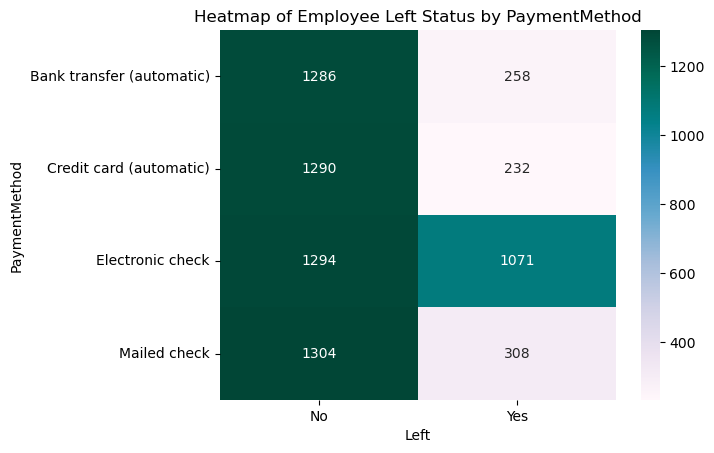

In [103]:
gp = df.groupby("PaymentMethod")["Left"].value_counts().unstack()
sns.heatmap(gp, annot=True, cmap="PuBuGn",fmt = ".0f")
plt.title("Heatmap of Employee Left Status by PaymentMethod")
plt.xlabel("Left")
plt.ylabel("PaymentMethod")
plt.show()


conclusion : customer is likely to churn when he is using electronic check as a payment method.

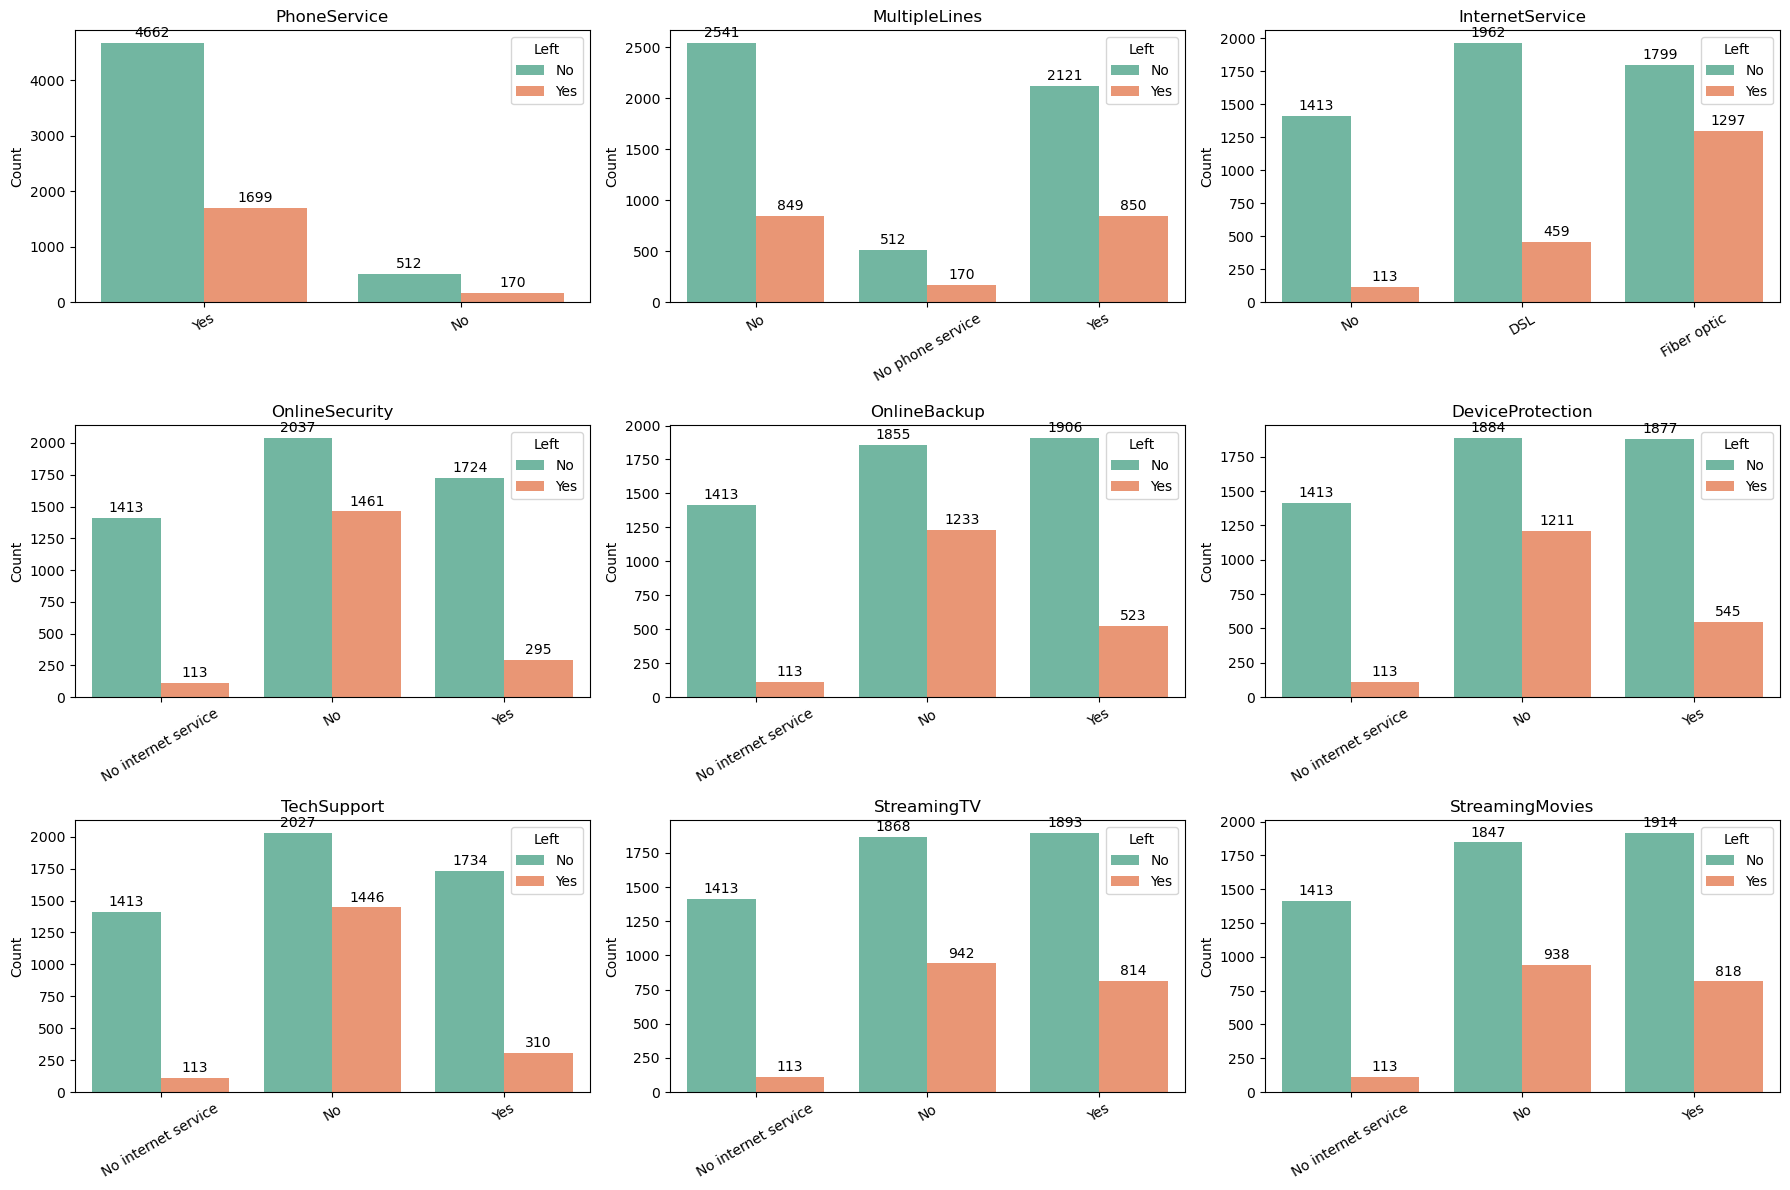

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of your columns
columns = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Number of plots
n = len(columns)

# Determine subplot grid size
rows = 3
cols = 3

# Set figure size
plt.figure(figsize=(18, 12))

# Create each subplot
for i, col in enumerate(columns, 1):
    plt.subplot(rows, cols, i)
    ax = sns.countplot(data=df, x=col, palette='Set2', hue="Left")
    plt.title(col)
    plt.xlabel('')
    plt.ylabel('Count')
    plt.xticks(rotation=30)

    # Add count labels to bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', padding=2)

# Adjust layout
plt.tight_layout()
plt.show()


Conclusion : The visual summary reveals clear trends related to customer churn. Customers without internet-related services (like OnlineSecurity, TechSupport, and Streaming) are less likely to churn, while those with these services show higher churn rates. Most churned users had PhoneService and InternetService, suggesting dissatisfaction despite having multiple services. Features like OnlineBackup and DeviceProtection also show higher churn among users who opted in.

# Final conclusion 

Churn Rate : A significantly larger number of customers chose not to churn, but the churn group is still substantial and demands attention.

Gender & Churn : Churn rates are almost equal between males and females, indicating gender isn't a strong driver of churn.

Senior Citizens : Senior citizens have a higher churn proportionally compared to non-senior customers, suggesting they may need more support or tailored plans.

Contract Type Impact : Customers on month-to-month contracts churn far more than those on longer-term contracts, indicating long-term plans help improve retention.

Service Usage Patterns : Customers who lack additional services (like OnlineSecurity, TechSupport, or Streaming) are more likely to stay, while those with multiple services tend to churn more—possibly due to complexity or cost dissatisfaction.

Outlet Data (From earlier pie and bar charts) : Medium-sized and Tier 3 outlets generate the highest total sales, which may relate to greater customer volume or preference for mid-sized accessible stores.